In [80]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("main-data/data disinformasi-hoaks.csv") # data utamanya kusimpen di main-data, soalnya pusing
data

,title,content,classification
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",hoax
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,disinformation
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",hoax
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",disinformation
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,hoax
...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,hoax
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,hoax
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,hoax
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,hoax


In [81]:
data_revisi = pd.read_csv("main-data/data disinformasi-hoaks V2 - revisi label.csv")
print(len(data_revisi))

16947


In [82]:
data_revisi["content"][0]

'Beredar di media sosial, sebuah informasi yang mengklaim bahwa Indomilk atau PT Indolakto tengah membagikan hadiah jutaan rupiah dalam rangka perayaan ulang tahun ke-55 Indomilk. Unggahan tersebut disertai dengan sebuah tautan yang berisi kuesioner untuk mendapatkan hadiah..<div><br></div><div>Faktanya, melalui akun Instagram resminya @indomilk.kentalmanis, PT Indolakto membantah informasi yang beredar tersebut. Pihaknya mengimbau masyarakat untuk tetap berhati-hati terhadap modus penipuan yang mengatasnamakan Indomilk.</div>'

In [83]:
data_revisi.isna().sum()

title                0
content           2857
classification       0
dtype: int64

In [84]:
data_kosong = data_revisi[data_revisi["content"].isna()]
data_nonkosong = data_revisi[data_revisi["content"].notna()]

In [85]:
data_nonkosong

,title,content,classification
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",Disinformasi
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,Disinformasi
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",Disinformasi
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",Disinformasi
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,Disinformasi
...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,Disinformasi
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,Disinformasi
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,Disinformasi
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,Disinformasi


In [86]:
import re
import numpy as np
from bs4 import BeautifulSoup

"""
bersihin tag html tapi simpen link yang ada di anchor (<a>)
"""

def bersihtag(teks):
    if not isinstance(teks, str):
        return np.nan
    
    soup = BeautifulSoup(teks, "html.parser")
    links = [a.get("href") for a in soup.find_all("a") if a.get("href")]

    sumber_berita = links if links else np.nan
    
    clean_text = soup.get_text(separator=" ")
    clean_text = re.sub(r'\s+', ' ', clean_text).strip() # hapus &nbsp;
    clean_text = clean_text.replace('\xa0', ' ') 

    return clean_text, sumber_berita

hasil = data_nonkosong["content"].apply(bersihtag).apply(pd.Series)

data_nonkosong["content_clean"] = hasil[0]
data_nonkosong["sumber_berita"] = hasil[1]

In [87]:
hasil

,0,1
0,"Beredar di media sosial, sebuah informasi yang...",NaN
1,Beredar sebuah foto di media sosial yang mempe...,NaN
2,Beredar di media sosial TikTok tangkapan layar...,NaN
3,Beredar beberapa akun Facebook mengatasnamakan...,NaN
4,Beredar informasi di media sosial sebuah akun ...,NaN
...,...,...
16942,Beredar sebuah unggahan video di media sosial ...,[https://www.kompas.com/cekfakta/read/2026/02/...
16943,Beredar sebuah unggahan di media sosial Facebo...,[https://turnbackhoax.id/articles/32502-penipu...
16944,Beredar unggahan video di media sosial TikTok ...,[https://turnbackhoax.id/articles/32494-penipu...
16945,Beredar sebuah unggahan di media sosial yang m...,[https://www.kompas.com/cekfakta/read/2026/02/...


In [88]:
data_nonkosong

,title,content,classification,content_clean,sumber_berita
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",Disinformasi,"Beredar di media sosial, sebuah informasi yang...",NaN
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,Disinformasi,Beredar sebuah foto di media sosial yang mempe...,NaN
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",Disinformasi,Beredar di media sosial TikTok tangkapan layar...,NaN
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",Disinformasi,Beredar beberapa akun Facebook mengatasnamakan...,NaN
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,Disinformasi,Beredar informasi di media sosial sebuah akun ...,NaN
...,...,...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,Disinformasi,Beredar sebuah unggahan video di media sosial ...,[https://www.kompas.com/cekfakta/read/2026/02/...
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,Disinformasi,Beredar sebuah unggahan di media sosial Facebo...,[https://turnbackhoax.id/articles/32502-penipu...
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,Disinformasi,Beredar unggahan video di media sosial TikTok ...,[https://turnbackhoax.id/articles/32494-penipu...
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,Disinformasi,Beredar sebuah unggahan di media sosial yang m...,[https://www.kompas.com/cekfakta/read/2026/02/...


In [89]:
mastiintitle = data_nonkosong["title"]

mastiintitle.to_csv("mastiintitle.csv", index=False)

In [90]:
import re

def clean_title(text):
    if not isinstance(text, str): return ""
    quotes_variants = r'["\'“”‘’„‟«»`]'
    text = re.sub(quotes_variants, '', text)
    text = text.strip()
    text = " ".join(text.split())
    
    return text

# nyoba
judul_kotor = '"Akun WhatsApp Mengatasnamakan Kadis Peternakan dan Kesehatan Hewan Lebak Banten Rahmat Yuniar, SP., M.Si."'

print("sebelum:", judul_kotor)
print("sesudah:", clean_title(judul_kotor))

data_nonkosong['clean_title'] = data_nonkosong['title'].apply(clean_title)
data_kosong['clean_title'] = data_kosong['title'].apply(clean_title)

sebelum: "Akun WhatsApp Mengatasnamakan Kadis Peternakan dan Kesehatan Hewan Lebak Banten Rahmat Yuniar, SP., M.Si."
sesudah: Akun WhatsApp Mengatasnamakan Kadis Peternakan dan Kesehatan Hewan Lebak Banten Rahmat Yuniar, SP., M.Si.


In [91]:
data_nonkosong

,title,content,classification,content_clean,sumber_berita,clean_title
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",Disinformasi,"Beredar di media sosial, sebuah informasi yang...",NaN,Indomilk Bagi-bagi Hadiah Jutaan Rupiah
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,Disinformasi,Beredar sebuah foto di media sosial yang mempe...,NaN,"Video Buaya Memakan Orang di Daerah Bodeh, Com..."
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",Disinformasi,Beredar di media sosial TikTok tangkapan layar...,NaN,Presiden Jokowi Resmikan Bendera Indonesia Ter...
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",Disinformasi,Beredar beberapa akun Facebook mengatasnamakan...,NaN,Tautan Hadiah Khusus Nasabah BPD Bali
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,Disinformasi,Beredar informasi di media sosial sebuah akun ...,NaN,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...
...,...,...,...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,Disinformasi,Beredar sebuah unggahan video di media sosial ...,[https://www.kompas.com/cekfakta/read/2026/02/...,Puan Maharani Informasikan Dana Bantuan untuk ...
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,Disinformasi,Beredar sebuah unggahan di media sosial Facebo...,[https://turnbackhoax.id/articles/32502-penipu...,Tautan Pendaftaran Undian Berhadiah Bank Sulut...
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,Disinformasi,Beredar unggahan video di media sosial TikTok ...,[https://turnbackhoax.id/articles/32494-penipu...,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,Disinformasi,Beredar sebuah unggahan di media sosial yang m...,[https://www.kompas.com/cekfakta/read/2026/02/...,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...


In [92]:
data_nonkosong["banyak_kata_content"] = data_nonkosong["content_clean"].str.split().str.len()
data_nonkosong["banyak_kata_title"] = data_nonkosong["clean_title"].str.split().str.len()

# buat yang content kosong, cek panjang judul
data_kosong["banyak_kata_title"] = data_kosong["clean_title"].str.split().str.len()

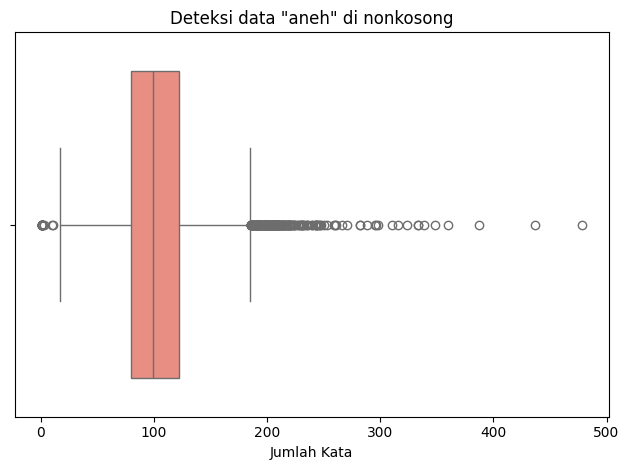

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=data_nonkosong['banyak_kata_content'], color='salmon')
plt.title('Deteksi data "aneh" di nonkosong')
plt.xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

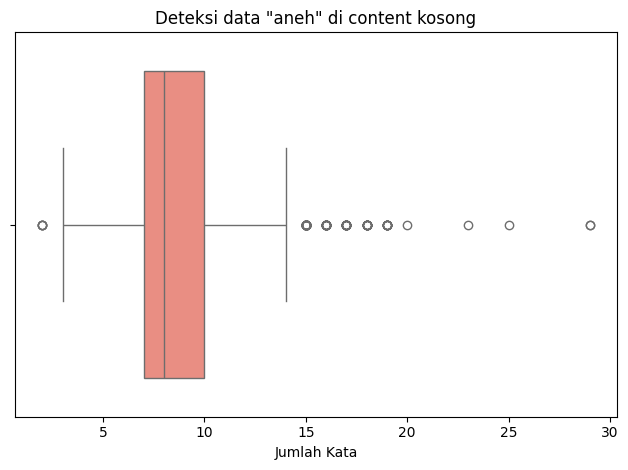

In [94]:
sns.boxplot(x=data_kosong['banyak_kata_title'], color='salmon')
plt.title('Deteksi data "aneh" di content kosong')
plt.xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

In [95]:
anon = data_kosong[data_kosong["banyak_kata_title"] == 29]

In [96]:
anon

,title,content,classification,clean_title,banyak_kata_title
3372,Pasca terjadinya gempa Donggala yang berkekuat...,NaN,Disinformasi,Pasca terjadinya gempa Donggala yang berkekuat...,29
3421,Beredar di media sosial undangan yang mengatas...,NaN,Disinformasi,Beredar di media sosial undangan yang mengatas...,29


In [97]:
anomali = data_nonkosong[(data_nonkosong["banyak_kata_content"] <= 20) | (data_nonkosong["banyak_kata_title"] <= 1)]
anomali

,title,content,classification,content_clean,sumber_berita,clean_title,banyak_kata_content,banyak_kata_title
631,test 12 januari,tes,Disinformasi,tes,NaN,test 12 januari,1,3
1270,"“OPERAIND""",Beberapa waktu belakangan banyak beredar berit...,Disinformasi,Beberapa waktu belakangan banyak beredar berit...,NaN,OPERAIND,109,1
2218,Judul isu dua,Narasi isu dua,Disinformasi,Narasi isu dua,NaN,Judul isu dua,3,3
6323,ina minta Jokowi jual pulau jawa dan sumatra,empty,Disinformasi,empty,NaN,ina minta Jokowi jual pulau jawa dan sumatra,1,8
6342,eluarga menutup keranda mayit dengan karpet ak...,empty,Disinformasi,empty,NaN,eluarga menutup keranda mayit dengan karpet ak...,1,14
6792,Survei kemenangan Prabowo,empty,Disinformasi,empty,NaN,Survei kemenangan Prabowo,1,3
7056,tes title diganti,Warteg di Pasar Pramuka Mengalami Kerugian Set...,Disinformasi,Warteg di Pasar Pramuka Mengalami Kerugian Set...,NaN,tes title diganti,10,3
7918,tes7jul,hasil periksa fakta Rahmah a n (UIN Sunan Ampe...,Disinformasi,hasil periksa fakta Rahmah a n (UIN Sunan Ampe...,NaN,tes7jul,25,1
13169,rabowo Sandi dinanti dunia !,"Foto yang beredar adalah hasil suntingan, meng...",Disinformasi,"Foto yang beredar adalah hasil suntingan, meng...",NaN,rabowo Sandi dinanti dunia !,19,5
13629,odus pencurian menggunakan Stiker Call Center ...,empty,Disinformasi,empty,NaN,odus pencurian menggunakan Stiker Call Center ...,1,13


In [98]:
mask_anomali = (data_nonkosong["banyak_kata_content"] <= 20) | (data_nonkosong["banyak_kata_title"] <= 1)

anomali = data_nonkosong[mask_anomali]
noAnomali = data_nonkosong[~mask_anomali]

In [99]:
print(noAnomali["content"][0])

Beredar di media sosial, sebuah informasi yang mengklaim bahwa Indomilk atau PT Indolakto tengah membagikan hadiah jutaan rupiah dalam rangka perayaan ulang tahun ke-55 Indomilk. Unggahan tersebut disertai dengan sebuah tautan yang berisi kuesioner untuk mendapatkan hadiah..<div><br></div><div>Faktanya, melalui akun Instagram resminya @indomilk.kentalmanis, PT Indolakto membantah informasi yang beredar tersebut. Pihaknya mengimbau masyarakat untuk tetap berhati-hati terhadap modus penipuan yang mengatasnamakan Indomilk.</div>


In [100]:
# noAnomali.to_csv("noAnomali.csv", index=False)

In [101]:

"""
ga jadi dipake, kita ambil web aslinya bukan yang direfer di penjelasan. 
kusimpen siapa tau strategi nya ganti lagi
"""

def ambil_link(teks):
    if not isinstance(teks, str) or teks == "":
        return np.nan
    
    soup = BeautifulSoup(teks, "html.parser")
    links = [a.get("href") for a in soup.find_all("a") if a.get("href")]
    if not links:
        return np.nan

    return links

# noAnomali["sumber_berita"] = noAnomali["content"].apply(ambil_link)

# noAnomali_noSumber = noAnomali[noAnomali["sumber_berita"].isna()]
# noAnomali_validSumber = noAnomali[noAnomali["sumber_berita"].notna()]

In [102]:
"""
ini juga awalnya, buat yang ga ada anchor kita cari polanya aja gitu, terus ambil portal berita

misalnya, dilansir dari "portalBerita.com", nah itu yang diambil. tapi ga jadi lagi kan
"""

def sumber(text):
    """
    bedanya ini kita ambil dari "dilansir dari ---.com"
    """
    if not isinstance(text, str): return None

    # Regex ini mencari "dilansir dari" (case insensitive) 
    # lalu mengambil kata setelahnya yang mengandung titik (biar dapet domain)
    # \s+ = spasi satu atau lebih
    # ([\w\.-]+\.[a-z]{2,}) = menangkap domain (contoh: liputan6.com)
    pattern = r"[Dd]ilansir dari\s+([\w\.-]+\.[a-z]{2,})\b"

    match = re.search(pattern, text)
    if match:
        return match.group(1).lower() # Ambil grup pertama (domainnya)
    return None

# noAnomali_noSumber['sumber_berita_'] = noAnomali_noSumber['content'].apply(sumber)

In [103]:
noAnomali_bersih = noAnomali[["clean_title", "content_clean", "classification"]] 
noAnomali_bersih.to_csv("noAnomali_bersih.csv", index=False)

In [104]:
noAnomali_bersih["classification"].value_counts()

classification
Disinformasi    14056
Name: count, dtype: int64

In [105]:
duplicateno = noAnomali_bersih.drop_duplicates(subset=["clean_title"], keep='first')
print(len(noAnomali))
print(len(duplicateno))
print(f"ilang sebanyak {len(noAnomali) - len(duplicateno)}")

duplicateno.to_csv("duplicateno.csv", index=False)

14056
13990
ilang sebanyak 66


In [106]:
# import os

"""
buat sampling jadi 1000 1000 per csv, soalnya rencananya mau pake selenium kan buat ambil url sumbernya
"""

# input_file = "noAnomali_bersih.csv"
# output_folder = "data"
# os.makedirs(output_folder, exist_ok=True)

# df = pd.read_csv(input_file)

# chunk_size = 1000

# num_chunks = (len(df) // chunk_size) + 1

# for i in range(num_chunks):
#     start = i * chunk_size
#     end = start + chunk_size
    
#     chunk = df.iloc[start:end]
    
#     if len(chunk) == 0:
#         break
        
#     output_path = os.path.join(output_folder, f"csv{i+1}.csv")
#     chunk.to_csv(output_path, index=False)

# print("done")

'\nbuat sampling jadi 1000 1000 per csv, soalnya rencananya mau pake selenium kan buat ambil url sumbernya\n'

## Mecah kolom content jadi content + reason

In [107]:
import os

os.makedirs("catatan", exist_ok=True) 
os.makedirs("catatan/flagyes", exist_ok=True) 

In [108]:
df = pd.read_csv('duplicateno.csv')

"""
kolom baru
claim: kayak latar belakang nya gitu
reasoning: kayak bantahannya
done: flag, biar gampang filternya

"""
if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    
    # pola nya
    pattern = re.compile(r'(?<=[."])\s*(faktanya[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        # parts[0] = Teks sebelum "Faktanya" (claim-nya)
        # parts[1] = Kata "Faktanya" itu sendiri
        # parts[2] = Teks setelah "Faktanya" (reason-nya)
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

# 2. Jalankan Iterasi Tahap 1
print("Memproses pola 'Faktanya'...")
df1 = df.apply(process_pattern, axis=1)

# 3. Cek statistik
total_done = df1['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df1)} data.")

# 4. Simpan hasil
df1.to_csv('catatan/dataset_cleaned_step1.csv', index=False)

Memproses pola 'Faktanya'...
Berhasil memecah 9953 dari 13990 data.


In [109]:
df1

,clean_title,content_clean,classification,claim,reasoning,done
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",Disinformasi,"Beredar di media sosial, sebuah informasi yang...","Faktanya, melalui akun Instagram resminya @ind...",True
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,Disinformasi,Beredar sebuah foto di media sosial yang mempe...,"Faktanya, setelah ditelusuri kejadian tersebut...",True
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,Beredar di media sosial TikTok tangkapan layar...,Disinformasi,Beredar di media sosial TikTok tangkapan layar...,"Faktanya, klaim yang mengatakan bahwa Presiden...",True
3,Tautan Hadiah Khusus Nasabah BPD Bali,Beredar beberapa akun Facebook mengatasnamakan...,Disinformasi,Beredar beberapa akun Facebook mengatasnamakan...,"Faktanya, dilansir dari kompas.com, akun-akun ...",True
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,Disinformasi,Beredar informasi di media sosial sebuah akun ...,"Faktanya, akun WhatsApp dengan nomor (08569563...",True
...,...,...,...,...,...,...
13985,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,Disinformasi,Beredar sebuah unggahan video di media sosial ...,"Faktanya, klaim dalam unggahan tersebut adalah...",True
13986,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,Disinformasi,Beredar sebuah unggahan di media sosial Facebo...,"Faktanya, klaim tersebut adalah tidak benar. D...",True
13987,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,Disinformasi,Beredar unggahan video di media sosial TikTok ...,"Faktanya, klaim tersebut adalah tidak benar. D...",True
13988,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang m...,Disinformasi,Beredar sebuah unggahan di media sosial yang m...,"Faktanya, klaim Pemain Timnas Bulgaria Tiba di...",True


In [110]:
flagno1 = df1[df1["done"] == False]
flagno1.to_csv("catatan/flagno1.csv", index=False)

flagyes1 = df1[df1["done"] == True]
flagyes1.to_csv("catatan/flagyes/flagyes1.csv", index=False)

In [111]:
df = pd.read_csv('catatan/flagno1.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    
    pattern = re.compile(r'(faktanya Setelah ditelusuri[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'faktanya Setelah ditelusuri'...")
df2 = df.apply(process_pattern, axis=1)

total_done = df2['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df2)} data.")
df2.to_csv('catatan/dataset_cleaned_step2.csv', index=False)

Memproses pola 'faktanya Setelah ditelusuri'...
Berhasil memecah 14 dari 4037 data.


In [112]:
flagno2 = df2[df2["done"] == False]
flagno2.to_csv("catatan/flagno2.csv", index=False)

flagyes2 = df2[df2["done"] == True]
flagyes2.to_csv("catatan/flagyes/flagyes2.csv", index=False)

#### 2. Berdasarkan kata dilansir

In [113]:
df = pd.read_csv('catatan/flagno2.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    
    pattern = re.compile(r'(?<=[."”])\s*(dilansir[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'dilansir'...")
df3 = df.apply(process_pattern, axis=1)

total_done = df3['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df3)} data.")
df3.to_csv('catatan/dataset_cleaned_step3.csv', index=False)

Memproses pola 'dilansir'...
Berhasil memecah 1296 dari 4023 data.


In [114]:
flagno3 = df3[df3["done"] == False]
flagno3.to_csv("catatan/flagno3.csv", index=False)

flagyes3 = df3[df3["done"] == True]
flagyes3.to_csv("catatan/flagyes/flagyes3.csv", index=False)

In [115]:
df = pd.read_csv('catatan/flagno3.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean'])
    pattern = re.compile(r'(?<=[."”])\s*(berdasarkan hasil penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'berdasarkan hasil penelusuran'...")
df4 = df.apply(process_pattern, axis=1)

total_done = df4['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df4)} data.")
df4.to_csv('catatan/dataset_cleaned_step4.csv', index=False)

Memproses pola 'berdasarkan hasil penelusuran'...
Berhasil memecah 145 dari 2727 data.


In [116]:
flagno4 = df4[df4["done"] == False]
flagno4.to_csv("catatan/flagno4.csv", index=False)

flagyes4 = df4[df4["done"] == True]
flagyes4.to_csv("catatan/flagyes/flagyes4.csv", index=False)

In [117]:
df = pd.read_csv('catatan/flagno4.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean'])
    pattern = re.compile(r'(?<=[."”])\s*(Menanggapi[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Menanggapi'...")
df5 = df.apply(process_pattern, axis=1)

total_done = df5['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df5)} data.")
df5.to_csv('catatan/dataset_cleaned_step5.csv', index=False)

Memproses pola 'Menanggapi'...
Berhasil memecah 209 dari 2582 data.


In [118]:
flagno5 = df5[df5["done"] == False]
flagno5.to_csv("catatan/flagno5.csv", index=False)

flagyes5 = df5[df5["done"] == True]
flagyes5.to_csv("catatan/flagyes/flagyes5.csv", index=False)

In [119]:
df = pd.read_csv('catatan/flagno5.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(dikutip dari[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'dikutip dari'...")
df6 = df.apply(process_pattern, axis=1)

total_done = df6['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df6)} data.")
df6.to_csv('catatan/dataset_cleaned_step6.csv', index=False)

Memproses pola 'dikutip dari'...
Berhasil memecah 314 dari 2373 data.


In [120]:
flagno6 = df6[df6["done"] == False]
flagno6.to_csv("catatan/flagno6.csv", index=False)

flagyes6 = df6[df6["done"] == True]
flagyes6.to_csv("catatan/flagyes/flagyes6.csv", index=False)

In [121]:
df = pd.read_csv('catatan/flagno6.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(Setelah ditelusuri lebih lanjut[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Setelah ditelusuri lebih lanjut'...")
df7 = df.apply(process_pattern, axis=1)

total_done = df7['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df7)} data.")
df7.to_csv('catatan/dataset_cleaned_step7.csv', index=False)

Memproses pola 'Setelah ditelusuri lebih lanjut'...
Berhasil memecah 239 dari 2059 data.


In [122]:
flagno7 = df7[df7["done"] == False]
flagno7.to_csv("catatan/flagno7.csv", index=False)

flagyes7 = df7[df7["done"] == True]
flagyes7.to_csv("catatan/flagyes/flagyes7.csv", index=False)

In [123]:
df = pd.read_csv('catatan/flagno7.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(?<=[.])\s*(Setelah di telusuri[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Setelah ditelusuri lebih lanjut'...")
df8 = df.apply(process_pattern, axis=1)

total_done = df8['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df8)} data.")
df8.to_csv('catatan/dataset_cleaned_step8.csv', index=False)

Memproses pola 'Setelah ditelusuri lebih lanjut'...
Berhasil memecah 4 dari 1820 data.


In [124]:
flagno8 = df8[df8["done"] == False]
flagno8.to_csv("catatan/flagno8.csv", index=False)

flagyes8 = df8[df8["done"] == True]
flagyes8.to_csv("catatan/flagyes/flagyes8.csv", index=False)

In [125]:
df = pd.read_csv('catatan/flagno8.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(?<=[.])\s*(namun faktanya[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'namun faktanya'...")
df9 = df.apply(process_pattern, axis=1)

total_done = df9['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df9)} data.")
df9.to_csv('catatan/dataset_cleaned_step9.csv', index=False)

Memproses pola 'namun faktanya'...
Berhasil memecah 2 dari 1816 data.


In [126]:
flagno9 = df9[df9["done"] == False]
flagno9.to_csv("catatan/flagno9.csv", index=False)

flagyes9 = df9[df9["done"] == True]
flagyes9.to_csv("catatan/flagyes/flagyes9.csv", index=False)

In [127]:
df = pd.read_csv('catatan/flagno9.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(Faktanya, setelah dilakukan penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Faktanya, setelah dilakukan penelusuran'...")
df10 = df.apply(process_pattern, axis=1)

total_done = df10['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df10)} data.")
df10.to_csv('catatan/dataset_cleaned_step10.csv', index=False)

Memproses pola 'Faktanya, setelah dilakukan penelusuran'...
Berhasil memecah 2 dari 1814 data.


In [128]:
flagno10 = df10[df10["done"] == False]
flagno10.to_csv("catatan/flagno10.csv", index=False)

flagyes10 = df10[df10["done"] == True]
flagyes10.to_csv("catatan/flagyes/flagyes10.csv", index=False)

In [129]:
df = pd.read_csv('catatan/flagno10.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(adapun faktanya[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'adapun faktanya'...")
df11 = df.apply(process_pattern, axis=1)

total_done = df11['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df11)} data.")
df11.to_csv('catatan/dataset_cleaned_step11.csv', index=False)

Memproses pola 'adapun faktanya'...
Berhasil memecah 33 dari 1812 data.


In [130]:
flagno11 = df11[df11["done"] == False]
flagno11.to_csv("catatan/flagno11.csv", index=False)

flagyes11 = df11[df11["done"] == True]
flagyes11.to_csv("catatan/flagyes/flagyes11.csv", index=False)

In [131]:
df = pd.read_csv('catatan/flagno11.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(faktanya Setelah dilakukan penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'faktanya Setelah dilakukan penelusuran'...")
df12 = df.apply(process_pattern, axis=1)

total_done = df12['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df12)} data.")
df12.to_csv('catatan/dataset_cleaned_step12.csv', index=False)

Memproses pola 'faktanya Setelah dilakukan penelusuran'...
Berhasil memecah 6 dari 1779 data.


In [132]:
flagno12 = df12[df12["done"] == False]
flagno12.to_csv("catatan/flagno12.csv", index=False)

flagyes12 = df12[df12["done"] == True]
flagyes12.to_csv("catatan/flagyes/flagyes12.csv", index=False)

In [133]:
df = pd.read_csv('catatan/flagno12.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(namun setelah dilakukan penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'namun setelah dilakukan penelusuran'...")
df13 = df.apply(process_pattern, axis=1)

total_done = df13['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df13)} data.")
df13.to_csv('catatan/dataset_cleaned_step13.csv', index=False)

Memproses pola 'namun setelah dilakukan penelusuran'...
Berhasil memecah 6 dari 1773 data.


In [134]:
flagno13 = df13[df13["done"] == False]
flagno13.to_csv("catatan/flagno13.csv", index=False)

flagyes13 = df13[df13["done"] == True]
flagyes13.to_csv("catatan/flagyes/flagyes13.csv", index=False)

In [135]:
df = pd.read_csv('catatan/flagno13.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(?<=[.])\s*(Setelah dilakukan penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Setelah dilakukan penelusuran'...")
df14 = df.apply(process_pattern, axis=1)

total_done = df14['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df14)} data.")
df14.to_csv('catatan/dataset_cleaned_step14.csv', index=False)

Memproses pola 'Setelah dilakukan penelusuran'...
Berhasil memecah 104 dari 1767 data.


In [136]:
flagno14 = df14[df14["done"] == False]
flagno14.to_csv("catatan/flagno14.csv", index=False)

flagyes14 = df14[df14["done"] == True]
flagyes14.to_csv("catatan/flagyes/flagyes14.csv", index=False)

In [137]:
df = pd.read_csv('catatan/flagno14.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'((?:dan\s+)?setelah dilakukan penelusuran[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Setelah dilakukan penelusuran'...")
df15 = df.apply(process_pattern, axis=1)

total_done = df15['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df15)} data.")
df15.to_csv('catatan/dataset_cleaned_step15.csv', index=False)

Memproses pola 'Setelah dilakukan penelusuran'...
Berhasil memecah 11 dari 1663 data.


In [138]:
flagno15 = df15[df15["done"] == False]
flagno15.to_csv("catatan/flagno15.csv", index=False)

flagyes15 = df15[df15["done"] == True]
flagyes15.to_csv("catatan/flagyes/flagyes15.csv", index=False)

In [139]:
df = pd.read_csv('catatan/flagno15.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) # Asumsi kolom asli namanya ini
    pattern = re.compile(r'(?<=[.])\s*(namun[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'namun'...")
df16 = df.apply(process_pattern, axis=1)

total_done = df16['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df16)} data.")
df16.to_csv('catatan/dataset_cleaned_step16.csv', index=False)

Memproses pola 'namun'...
Berhasil memecah 142 dari 1652 data.


In [140]:
flagno16 = df16[df16["done"] == False]
flagno16.to_csv("catatan/flagno16.csv", index=False)

flagyes16 = df16[df16["done"] == True]
flagyes16.to_csv("catatan/flagyes/flagyes16.csv", index=False)

In [141]:
df = pd.read_csv('catatan/flagno16.csv')

if 'claim' not in df.columns:
    df['claim'] = ""
    df['reasoning'] = ""
    df['done'] = False

def process_pattern(row):
    if row['done'] == True:
        return row
    
    text = str(row['content_clean']) 
    pattern = re.compile(r'(faktanya,\s*setelah ditelusuri[,:]?\s*|setelah ditelusuri[,:]?\s*)', re.IGNORECASE)
    parts = pattern.split(text, maxsplit=1)
    
    if len(parts) >= 3:
        row['claim'] = parts[0].strip()
        row['reasoning'] = (parts[1] + parts[2]).strip()
        row['done'] = True
    
    return row

print("Memproses pola 'Setelah dilakukan penelusuran'...")
df17 = df.apply(process_pattern, axis=1)

total_done = df17['done'].sum()
print(f"Berhasil memecah {total_done} dari {len(df17)} data.")
df17.to_csv('catatan/dataset_cleaned_step17.csv', index=False)

Memproses pola 'Setelah dilakukan penelusuran'...
Berhasil memecah 504 dari 1510 data.


In [142]:
"""
udah ga nemu polanya gw disini
"""

flagno17 = df17[df17["done"] == False]
flagno17 = flagno17[["clean_title", "content_clean", "classification"]]
flagno17.to_csv("summary/flagno17.csv", index=False)
flagno17.to_csv("catatan/flagno17.csv", index=False)

flagyes17 = df17[df17["done"] == True]
flagyes17.to_csv("catatan/flagyes/flagyes17.csv", index=False)

In [143]:
df17 

,clean_title,content_clean,classification,claim,reasoning,done
0,Surat Permintaan Data Pensiunan PNS dan ASN Te...,Beredar sebuah surat mengatasnamakan Direktora...,Disinformasi,NaN,NaN,False
1,Akun Instagram Mengatasnamakan Bupati Luwu Utara,Beredar sebuah akun Instagram yang mengatasnam...,Disinformasi,NaN,NaN,False
2,Akun WhatsApp Mengatasnamakan Pejabat Dinas Pe...,Beredar sebuah akun WhatsApp mengatasnamakan K...,Disinformasi,NaN,NaN,False
3,Covid-19 Berasal dari Laboratorium Ukraina,Beredar di media sosial Facebook sebuah unggah...,Disinformasi,Beredar di media sosial Facebook sebuah unggah...,"Setelah ditelusuri, video tersebut merupakan v...",True
4,Mahasiswa yang Demo Tolak Tiga Periode Diancam...,Beredar sebuah foto di media sosial Facebook d...,Disinformasi,Beredar sebuah foto di media sosial Facebook d...,"Setelah ditelusuri, klaim bahwa mahasiswa yang...",True
...,...,...,...,...,...,...
1505,Video Presiden Prabowo Tegas Usir Habib Baalawi,Beredar sebuah unggahan video di media sosial ...,Disinformasi,Beredar sebuah unggahan video di media sosial ...,"Setelah ditelusuri, video yang beredar merupak...",True
1506,Peserta BPJS PBI Dinonaktifkan oleh Pusat Mula...,Beredar di media sosial X atau Twitter unggaha...,Disinformasi,Beredar di media sosial X atau Twitter unggaha...,Setelah ditelusuri dengan kata kunci “Apakah B...,True
1507,Tautan Perpanjangan Pendaftaran Upacara HUT ke...,Beredar di media sosial TikTok mengatasnamakan...,Disinformasi,Beredar di media sosial TikTok mengatasnamakan...,Setelah ditelusuri dengan memasukkan kata kunc...,True
1508,Akun WhatsApp Mengatasnamakan Kadis PU Kabupat...,Beredar di aplikasi perpesanan WhatsApp sebuah...,Disinformasi,NaN,NaN,False


#### Gabungin Dataset

In [144]:
import glob

files = glob.glob("catatan/flagyes/*.csv")

data_gabungan = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
data_gabungan = data_gabungan[["clean_title","claim", "reasoning", "classification"]]

data_gabungan.to_csv("Datagabungan.csv", index=False)

In [145]:
data_gabungan

,clean_title,claim,reasoning,classification
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...","Faktanya, melalui akun Instagram resminya @ind...",Disinformasi
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,"Faktanya, setelah ditelusuri kejadian tersebut...",Disinformasi
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,Beredar di media sosial TikTok tangkapan layar...,"Faktanya, klaim yang mengatakan bahwa Presiden...",Disinformasi
3,Tautan Hadiah Khusus Nasabah BPD Bali,Beredar beberapa akun Facebook mengatasnamakan...,"Faktanya, dilansir dari kompas.com, akun-akun ...",Disinformasi
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,"Faktanya, akun WhatsApp dengan nomor (08569563...",Disinformasi
...,...,...,...,...
12979,Kerusuhan Suporter Persija Anggota Brimob Terl...,Telah beredar di media sosial tentang Kerusuha...,Setelah di telusuri faktanya Kabid Humas Polda...,Disinformasi
12980,Video Viral Letusan Merapi Hari Ini,Beredar video viral yang disebarkan melalui pe...,Setelah di telusuri video tersebut di upload t...,Disinformasi
12981,"Alinka Humaira Nurhanzah, cucunya ibu Hj. Kesa...",Beredar di whatsapp dan facebook isu penculika...,Setelah di telusuri informasi ini ternyata sud...,Disinformasi
12982,Sakit nya tuh disini,Akun Facebook atas nama Aang Riana (facebook.c...,Namun faktanya apa yang dikatakan oleh si anak...,Disinformasi


In [ ]:
import re

"""
udah pusing gweh, infoin aja kalo ada pattern lain
"""

import re

def super_clean_attribution(text):
    if not isinstance(text, str):
        return text
    
    # 1. Dilansir / Dikutip dari ... ,
    text = re.sub(
        r'(Dilansir|Dikutip)\s+dari\s+[^,]+\s*,\s*',
        '',
        text,
        flags=re.IGNORECASE,
        count=1
    )
    
    # 2. Tanpa koma (langsung domain)
    text = re.sub(
        r'(Dilansir|Dikutip)\s+dari\s+\S+\.(go\.id|id|com|net|org)\s*',
        '',
        text,
        flags=re.IGNORECASE,
        count=1
    )
    
    # 3. Hasil penelusuran dari ...
    text = re.sub(
        r'Hasil\s+penelusuran\s+dari\s+[^,]+\s*,\s*',
        '',
        text,
        flags=re.IGNORECASE,
        count=1
    )

    text = re.sub(r'\s+', ' ', text).strip()

    if text:
        text = text[0].upper() + text[1:]
        
    return text




In [ ]:
cek = pd.read_csv("summary/hasil_mistral_v3.csv")

In [ ]:
cek

,clean_title,content_clean,classification,claim,reasoning,done
0,Surat Permintaan Data Pensiunan PNS dan ASN Te...,Beredar sebuah surat mengatasnamakan Direktora...,hoax,Beredar sebuah surat mengatasnamakan Direktora...,Melalui akun Instagram resminya @bkngoidoffici...,True
1,Akun Instagram Mengatasnamakan Bupati Luwu Utara,Beredar sebuah akun Instagram yang mengatasnam...,hoax,Beredar sebuah akun Instagram yang mengatasnam...,Melalui akun Instagram pribadinya @indahnyalut...,True
2,Akun WhatsApp Mengatasnamakan Pejabat Dinas Pe...,Beredar sebuah akun WhatsApp mengatasnamakan K...,hoax,Beredar sebuah akun WhatsApp mengatasnamakan K...,Dinas Kominfo DIY melalui akun Twitter resminy...,True


In [ ]:
data_tambahan = pd.read_csv("main-data/Konten DFK Terverifikasi - Detail data recap.csv")

In [ ]:
data_clean = data_tambahan[data_tambahan["URL KONTEN"].notna()]
data_clean = data_clean.drop(data_clean[data_clean["PLATFORM"] == "#VALUE!"].index)
data_clean = data_clean[["ANALISIS PELANGGARAN", "ANALISIS DAMPAK", "DASAR HUKUM", "PLATFORM", "KATEGORI"]]

In [ ]:
data_clean.to_csv("data_clean.csv", index=False)

In [ ]:
data_clean["PLATFORM"].unique()


array(['Facebook', 'Twitter', 'Tiktok', nan, 'Instagram', 'Youtube',
       'Threads', 'FALSE', 'Media Online', 'Filesharing', 'Hoax'],
      dtype=object)

In [ ]:
target_map = {
    "TikTok" : "Tiktok",
    "TIkTok" : "Tiktok"
}

data_clean["PLATFORM"] = data_clean["PLATFORM"].replace(target_map)

In [ ]:
data_tambahan[data_tambahan["PLATFORM"] == "#VALUE!"]

,No,Tanggal,URL KONTEN,SCREEN CAPTURE,KATEGORI,PLATFORM,ANALISIS PELANGGARAN,DASAR HUKUM,ANALISIS DAMPAK,VERIFIKASI,KETERANGAN,Unnamed: 11
4053,4043.0,19 December 2025,16,NaN,NaN,#VALUE!,Konten ini mengandung unsur provokasi dan sepa...,NaN,NaN,Sudah Verifikasi,NaN,NaN


In [ ]:
data_tambahan[data_tambahan["PLATFORM"].isna()]

,No,Tanggal,URL KONTEN,SCREEN CAPTURE,KATEGORI,PLATFORM,ANALISIS PELANGGARAN,DASAR HUKUM,ANALISIS DAMPAK,VERIFIKASI,KETERANGAN,Unnamed: 11
13,14.0,7 September 2025,https://www.tiktok.com/@tuanmudatiro/video/754...,NaN,Ujaran Kebencian,NaN,Akun tersebut mengunggah narasi separatisme Ac...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,Munculnya akun dan/atau konten provokatif sepe...,Sudah Verifikasi,NaN,NaN
14,15.0,7 September 2025,https://x.com/gegala_/status/1964163492874682392,NaN,Ujaran Kebencian,NaN,Akun tersebut membuat unggahan dengan narasi p...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,Munculnya akun dan/atau konten provokatif sepe...,Sudah Verifikasi,NaN,NaN
15,16.0,7 September 2025,https://x.com/myshawti/status/1963936642399416422,NaN,Ujaran Kebencian,NaN,Sebuah akun mengunggah video dengan narasi Pol...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,Munculnya akun dan/atau konten provokatif sepe...,Sudah Verifikasi,NaN,NaN
16,17.0,7 September 2025,https://x.com/albinousie/status/19641894933819...,NaN,Ujaran Kebencian,NaN,Konten narasi ajakan demonstrasi dengan melaku...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,Munculnya akun dan/atau konten provokatif sepe...,Sudah Verifikasi,NaN,NaN
17,18.0,7 September 2025,https://x.com/red_troa/status/1963461982650278297,NaN,Ujaran Kebencian,NaN,Konten narasi penggerakan “people power“ untuk...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,Munculnya akun dan/atau konten provokatif sepe...,Sudah Verifikasi,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1408,1398.0,21 November 2025,https://www.facebook.com/story.php?story_fbid=...,NaN,NaN,NaN,Konten tersebut berisi provokasi terhadap masy...,NaN,NaN,Sudah Verifikasi,NaN,NaN
3982,3972.0,NaN,NaN,NaN,NaN,NaN,NaN,2. Pasal 28 ayat (2) Dijelaskan mengenai perbu...,NaN,NaN,NaN,NaN
4000,3990.0,NaN,NaN,NaN,NaN,NaN,NaN,2. Pasal 28 ayat (2) Dijelaskan mengenai perbu...,NaN,NaN,NaN,NaN
4037,4027.0,NaN,NaN,NaN,NaN,NaN,NaN,2. Pasal 28 ayat (2) Dijelaskan mengenai perbu...,NaN,NaN,NaN,NaN


In [ ]:
data_tambahan[data_tambahan["PLATFORM"] == "Media Online"] 

,No,Tanggal,URL KONTEN,SCREEN CAPTURE,KATEGORI,PLATFORM,ANALISIS PELANGGARAN,DASAR HUKUM,ANALISIS DAMPAK,VERIFIKASI,KETERANGAN,Unnamed: 11
523,513.0,16 September 2025,https://papua.tribunnews.com/news/119068/break...,NaN,NaN,Media Online,Kejadian pembakaran Hari ini Selasa 16 Septemb...,Pasal 160 KUHP dan Pasal 28 ayat (2),Dapat menimbulkan kericuhan antar umat suku di...,Belum Verifikasi,media,NaN


In [ ]:
data_tambahan[data_tambahan["URL KONTEN"].isna()]

,No,Tanggal,URL KONTEN,SCREEN CAPTURE,KATEGORI,PLATFORM,ANALISIS PELANGGARAN,DASAR HUKUM,ANALISIS DAMPAK,VERIFIKASI,KETERANGAN,Unnamed: 11
584,574.0,17 September 2025,NaN,NaN,NaN,FALSE,Ditemukan konten yang diduga memuat narasi pro...,Undang-Undang Nomor 1 Tahun 2024 tentang Perub...,"Munculnya akun dan/atau konten provokatif, uja...",Sudah Verifikasi,Tidak ada URL nya,NaN
1485,1475.0,2 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1487,1477.0,2 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1489,1479.0,2 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1516,1506.0,3 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1518,1508.0,3 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1520,1510.0,3 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1522,1512.0,3 October 2025,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN
1583,1573.0,6 October 2025,NaN,NaN,NaN,FALSE,Grup tersebut adalah grup SARA yang menggaungk...,NaN,NaN,Sudah Verifikasi,ok,NaN
1628,1618.0,NaN,NaN,NaN,NaN,FALSE,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cek = pd.read_csv("dataset_hasil_gabung_logis.csv")

In [ ]:
cek["DAMPAK_DAN_HUKUM"][10]

'Ajakan ini dapat memicu tindakan kericuhan di ruang publik. Tindakan yang menimbulkan dampak tersebut secara jelas bertentangan dengan Pasal 28 ayat (2) UU ITE Dijelaskan mengenai perbuatan seseorang yang menyebarkan kebencian terhadap suku, agama, ras, dan antargolongan (“SARA”) melalui media elektronik termasuk perbuatan yang dilarang, yang berbunyi sebagai berikut: “Setiap Orang dengan sengaja dan tanpa hak mendistribusikan dan/atau mentransmisikan Informasi Elektronik dan/atau Dokumen Elektronik yang sifatnya menghasut, mengajak, atau memengaruhi orang lain sehingga menimbulkan rasa kebencian atau permusuhan terhadap individu dan/atau kelompok masyarakat tertentu berdasarkan ras, kebangsaan, etnis, warna kulit, agama, kepercayaan, jenis kelamin, disabilitas mental, atau disabilitas fisik.”.'